<a href="https://colab.research.google.com/github/SSADD1/Xz/blob/main/VAE_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем: {device}")

Используем: cuda


In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


In [ ]:
class ImprovedVAE(nn.Module):


    def __init__(self, input_dim=784, latent_dim=32):
        super(ImprovedVAE, self).__init__()

        # === ЭНКОДЕР ===
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # === ДЕКОДЕР ===
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, input_dim),
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


model = ImprovedVAE(latent_dim=32).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров в модели: {total_params:,}")

Параметров в модели: 1,149,008


In [ ]:

BETA = 4.0
def loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + BETA * KLD, MSE.item(), KLD.item()

In [ ]:
# AdamW немного лучше Adam (правильная L2-регуляризация)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS = 10
history = {'loss': [], 'mse': [], 'kld': []}

model.train()
print(f"Начинаем обучение на {NUM_EPOCHS} эпох...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    total_loss = total_mse = total_kld = 0

    for data, _ in train_loader:
        data_flat = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data_flat)
        loss, mse, kld = loss_function(recon, data_flat, mu, logvar)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()
        total_mse  += mse
        total_kld  += kld

    n = len(train_loader.dataset)
    avg_loss = total_loss / n
    avg_mse  = total_mse  / n
    avg_kld  = total_kld  / n
    lr_now   = scheduler.get_last_lr()[0]

    history['loss'].append(avg_loss)
    history['mse'].append(avg_mse)
    history['kld'].append(avg_kld)

    scheduler.step()

    print(f"Эпоха {epoch:>2}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
          f"MSE: {avg_mse:.4f} | KLD: {avg_kld:.4f} | LR: {lr_now:.2e}")

print("\nОбучение завершено!")

Начинаем обучение на 10 эпох...

Эпоха  1/10 | Loss: 132.8072 | MSE: 105.2045 | KLD: 6.9007 | LR: 1.00e-03
Эпоха  2/10 | Loss: 109.5770 | MSE: 82.3084 | KLD: 6.8171 | LR: 1.00e-03
Эпоха  3/10 | Loss: 105.8064 | MSE: 77.8894 | KLD: 6.9792 | LR: 1.00e-03
Эпоха  4/10 | Loss: 103.8876 | MSE: 75.5115 | KLD: 7.0940 | LR: 1.00e-03
Эпоха  5/10 | Loss: 102.7172 | MSE: 74.0203 | KLD: 7.1742 | LR: 1.00e-03
Эпоха  6/10 | Loss: 100.2781 | MSE: 71.3160 | KLD: 7.2405 | LR: 5.00e-04
Эпоха  7/10 | Loss: 99.6479 | MSE: 70.5342 | KLD: 7.2784 | LR: 5.00e-04
Эпоха  8/10 | Loss: 99.1692 | MSE: 69.8857 | KLD: 7.3209 | LR: 5.00e-04
Эпоха  9/10 | Loss: 98.8702 | MSE: 69.3981 | KLD: 7.3680 | LR: 5.00e-04
Эпоха 10/10 | Loss: 98.4228 | MSE: 68.9143 | KLD: 7.3771 | LR: 5.00e-04

Обучение завершено!


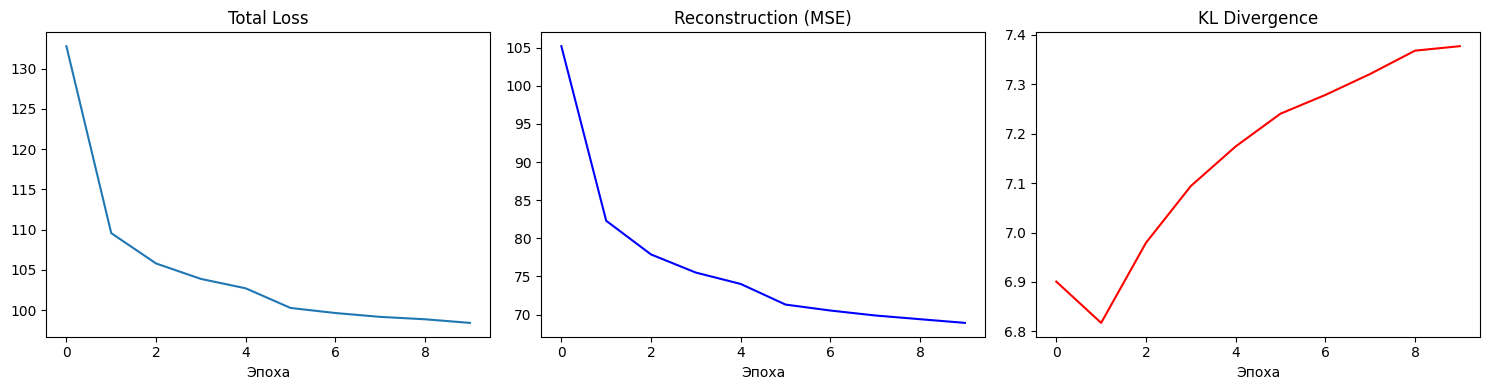

In [ ]:
# График обучения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'])
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Эпоха')

axes[1].plot(history['mse'], color='blue')
axes[1].set_title('Reconstruction (MSE)')
axes[1].set_xlabel('Эпоха')

axes[2].plot(history['kld'], color='red')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Эпоха')

plt.tight_layout()
plt.show()

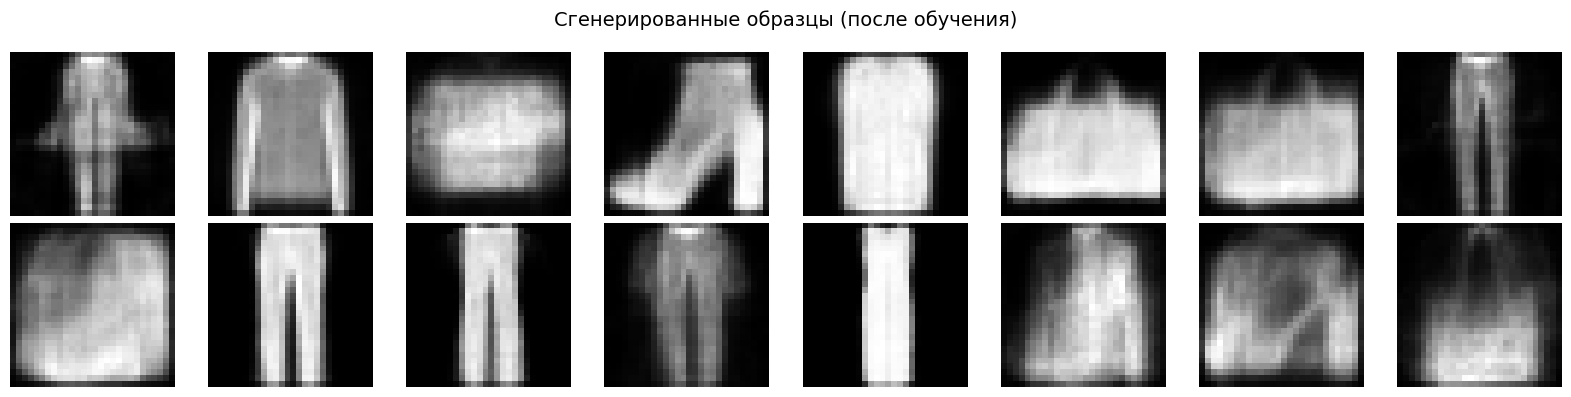

In [ ]:
# Генерация изображений из случайного шума
model.eval()
with torch.no_grad():
    z = torch.randn(16, 32).to(device)
    generated = model.decode(z).cpu()
    # Денормализуем обратно в [0, 1]
    generated = (generated * 0.5 + 0.5).clamp(0, 1)
    generated = generated.view(16, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Сгенерированные образцы (после обучения)', fontsize=14)
plt.tight_layout()
plt.show()

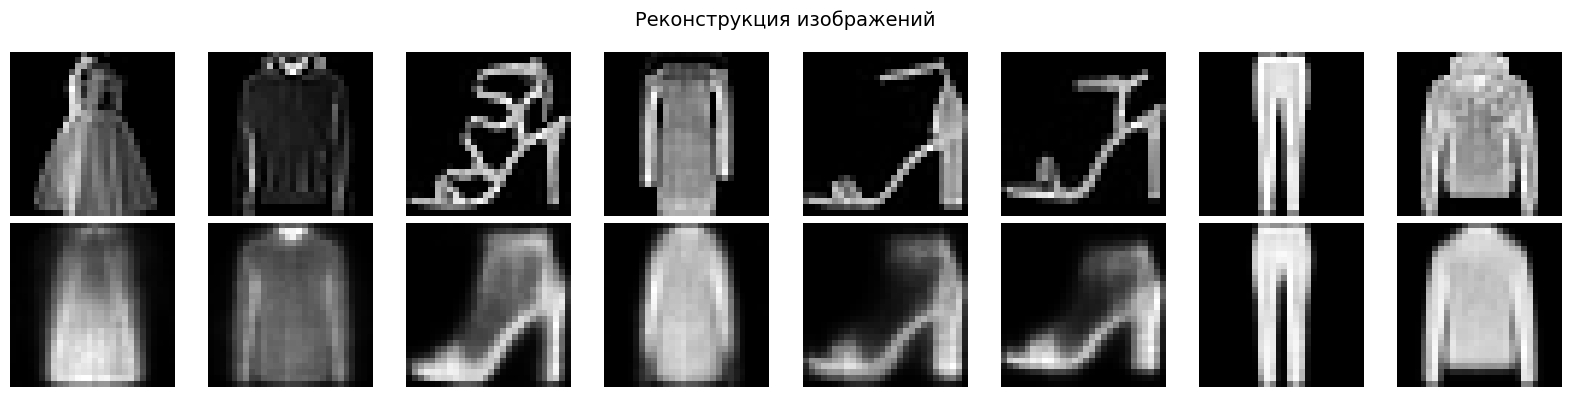

In [ ]:
# Реконструкция: оригинал vs восстановленное
model.eval()
sample_data, _ = next(iter(train_loader))
sample_flat = sample_data[:8].view(-1, 784).to(device)

with torch.no_grad():
    recon, _, _ = model(sample_flat)
    recon = (recon * 0.5 + 0.5).clamp(0, 1).cpu().view(8, 28, 28)
    orig  = (sample_data[:8] * 0.5 + 0.5).clamp(0, 1).squeeze()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(orig[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Оригинал', fontsize=12)
axes[1, 0].set_ylabel('Реконструкция', fontsize=12)
plt.suptitle('Реконструкция изображений', fontsize=14)
plt.tight_layout()
plt.show()

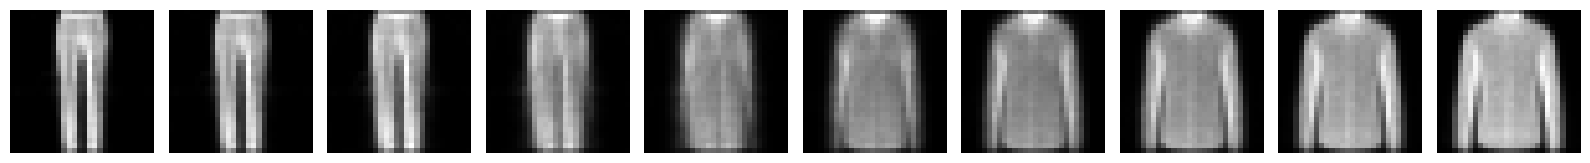

In [ ]:
model.eval()

with torch.no_grad():

    dataiter = iter(train_loader)
    images, labels = next(dataiter);

    img_A = images[0].view(-1, 784).to(device)
    img_B = images[1].view(-1, 784).to(device)

    h_A = model.encoder(img_A)
    mu_A = model.fc_mu(h_A)

    h_B = model.encoder(img_B)
    mu_B = model.fc_mu(h_B)

    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)

    plt.figure(figsize=(16, 3))

    for i, alpha in enumerate(alphas):
        # Математика интерполяции: z = (1 - alpha) * A + alpha * B
        z_interp = (1 - alpha) * mu_A + alpha * mu_B

        generated = model.decoder(z_interp)

        img_out = generated.view(28, 28).cpu().numpy()

        plt.subplot(1, steps, i + 1)
        plt.imshow(img_out, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()